In [1]:
from math import pi
import numpy as np
import scipy as sp
#from qiskit.opflow import CircuitSampler, StateFn, AerPauliExpectation, SparsePauliOp.
from qiskit.quantum_info import Pauli
from qiskit.circuit.library import PauliEvolutionGate
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.circuit import Parameter
from qiskit_algorithms.optimizers import COBYLA, SLSQP, SPSA, L_BFGS_B
from qiskit.circuit.library import TwoLocal
from qiskit_algorithms.optimizers import SciPyOptimizer
from qiskit.primitives import Sampler # new
#from qiskit.opflow.primitive_ops import SparsePauliOp. old
from qiskit.quantum_info import SparsePauliOp,PauliList
from qiskit.circuit import QuantumCircuit, QuantumRegister
#from qiskit.opflow.expectations import ExpectationFactory
from qiskit.primitives import Estimator # new
#from qiskit.opflow.state_fns import CircuitStateFn
#from qiskit.quantum_info import States old
import time
import pandas as pd
from qiskit.providers.basic_provider import BasicProvider #new
from multiprocessing import Pool
import multiprocessing as mp
from qiskit_algorithms.optimizers import SciPyOptimizer
import scipy as sp
from scipy.optimize import differential_evolution, Bounds
import os
from scipy.optimize import minimize
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.mappers.fermionic_mapper import FermionicMapper
from qiskit_nature.second_q.operators import FermionicOp
from qiskit.circuit import QuantumCircuit, QuantumRegister

In [2]:
JW = JordanWignerMapper()

a = lambda i: FermionicOp([("-_%i" % i, 1.)], num_spin_orbitals=2*N_sites)
a_dag = lambda i: ~a(i)

In [3]:
def H_hopping(t, N_sites):
    a = lambda i: FermionicOp({("+-_%i" % i,): 1.}, num_spin_orbitals=2*N_sites)
    a_dag = lambda i: a(i).adjoint()
    
    H_down = FermionicOp.zero()
    for k in range(N_sites):
        b = (k + 1) % N_sites
        H_down += -t * (a_dag(k) @ a(b) + a_dag(b) @ a(k))
    
    H_up = FermionicOp.zero()
    for k in range(N_sites, 2 * N_sites):
        b = (k + 1) % (2 * N_sites)
        H_up += -t * (a_dag(k) @ a(b) + a_dag(b) @ a(k))
    
    H = H_up + H_down
    JW = JordanWignerMapper()
    qubit_op = JW.map(H.simplify().normal_ordered()).reduce()
    
    return qubit_op

def H_hubb(U, N_sites):
    a = lambda i: FermionicOp({("+-_%i" % i,): 1.}, num_spin_orbitals=2*N_sites)
    a_dag = lambda i: a(i).adjoint()
    
    H_U = FermionicOp.zero()
    for k in range(N_sites):
        b = k + N_sites
        H_U += U * (a_dag(k) @ a(k) @ a_dag(b) @ a(b))
    
    JW = JordanWignerMapper()
    qubit_op = JW.map(H_U.simplify().normal_ordered()).reduce()
    
    return qubit_op

In [ ]:
from qiskit_nature.second_q.operators import FermionicOp
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.circuit.library import PauliEvolutionGate, TwoLocal
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import SparsePauliOp
from qiskit_algorithms import VQE, NumPyEigensolver
from qiskit.circuit import Parameter
from qiskit.synthesis import SuzukiTrotter
import numpy as np
import time

def H_hopping(t, N_sites):
    a = lambda i: FermionicOp({f"+_{i} -_{i}": 1.0}, num_spin_orbitals=2*N_sites)
    a_dag = lambda i: a(i).adjoint()
    
    H_down = FermionicOp.zero()
    for k in range(N_sites):
        b = (k + 1) % N_sites
        H_down += -t * (a_dag(k) @ a(b) + a_dag(b) @ a(k))
    
    H_up = FermionicOp.zero()
    for k in range(N_sites, 2 * N_sites):
        b = (k + 1) % (2 * N_sites)
        H_up += -t * (a_dag(k) @ a(b) + a_dag(b) @ a(k))
    
    H = H_up + H_down
    JW = JordanWignerMapper()
    qubit_op = JW.map(H.simplify().normal_order())
    
    return qubit_op

def H_hubb(U, N_sites):
    a = lambda i: FermionicOp({f"+_{i} -_{i}": 1.0}, num_spin_orbitals=2*N_sites)
    a_dag = lambda i: a(i).adjoint()
    
    H_U = FermionicOp.zero()
    for k in range(N_sites):
        b = k + N_sites
        H_U += U * (a_dag(k) @ a(k) @ a_dag(b) @ a(b))
    
    JW = JordanWignerMapper()
    qubit_op = JW.map(H_U.simplify().normal_order())
    
    return qubit_op

# Parameters
U = 1
t = 1
N_sites = 6

for u in [U]:
    ##################################### Hamiltonian ##########################################
    qubit_op = H_hubb(u, N_sites) + H_hopping(t, N_sites)

    ############################################################################################
    ##################################### Quantum circuit ######################################
    ############################################################################################
    reps = N_sites
    count = 0
    ansatz = QuantumCircuit(QuantumRegister(2 * N_sites))
    for r in range(reps):
        theta = Parameter(f't[{count}]')
        hamiltonian = SparsePauliOp.from_list([(str(pauli), coeff) for pauli, coeff in H_hubb(u, N_sites).to_list()])
        evol_gate = PauliEvolutionGate(hamiltonian, time=theta, synthesis=SuzukiTrotter(reps=1))
        ansatz.append(evol_gate, range(2 * N_sites))
        count += 1

        for pauli_string, coeff in H_hopping(t, N_sites).to_list():
            theta = Parameter(f't[{count}]')
            hamiltonian = SparsePauliOp.from_list([(pauli_string, coeff)])
            evol_gate = PauliEvolutionGate(hamiltonian, time=theta, synthesis=SuzukiTrotter(reps=1))
            ansatz.append(evol_gate, range(2 * N_sites))
            count += 1

    q_init = TwoLocal(qubit_op.num_qubits, ['ry'], 'cx', 'linear', reps=2, insert_barriers=True)    
    ansatz.compose(q_init, inplace=True, front=True)

    exact_solver = NumPyEigensolver(k=10)
    exact_result = exact_solver.compute_eigenvalues(qubit_op)
    print(exact_result.eigenvalues)

    # Save ground state energy for later
    gs_energy = np.round(exact_result.eigenvalues[0], 16)
    ############################################################################################

    ##################################### Instructions for the energy evaluation ###############################################
from qiskit_aer.primitives import Estimator

def evaluate_expectation(parameters_values):
    # Function to evaluate the expectation value of the Hamiltonian for a given set of parameters
    # Inputs: parameter_values (ndarray), parameter values
    # Outputs: result (float), energy value

    value_dict = dict(zip(ansatz.parameters, parameters_values))
    pars =  list(value_dict.values())
    expectation_value = estimator.run(ansatz,qubit_op,pars).result().values
    return np.real(expectation_value)

# Simulations are noiseless and without sampling. 
#backend = Aer.get_backend('aer_simulator') old
device = BasicProvider().get_backend('basic_simulator')
coupling_map = device.configuration().coupling_map
 
# If a noise model is provided, the Aer primitives
# perform a "qasm" simulation
estimator = Estimator(
            run_options={"shots": 64},
        )


class Individual:
    """Individual of the population. It holds parameters of the solution as well as the fitness of the solution."""
    def __init__(self, params, fitness):
        self.params = params
        self.fitness = fitness

    def __repr__(self):
        return '{} fitness: {}'.format(self.params, self.fitness)

def evaluate(params):
    return evaluate_expectation(params)

def generate_population(size, dimension, VarMin, VarMax):
    def cost_function_wrapper(params):
        return evaluate(params)

    pop = VarMin + np.random.rand(size, dimension) * (VarMax - VarMin)
    fitness = np.apply_along_axis(cost_function_wrapper, 1, pop)
    
    population = []
    for i in range(size):
        individual = Individual(pop[i], fitness[i])
        population.append(individual)

    return population

dimension = ansatz.num_parameters
# Control Parameters of SOMA
N_jump = 20  # Increase number of jumps
Step = 0.5  # Increase step size
PopSize = 200  # Increase population size
Max_FEs = 20 * dimension ** 4  # Increase maximum function evaluations
m = 15  # Increase number of migrants
n = 10  # Increase number of selected migrants
s = 20  # Increase number of potential leaders


# The domain (search space)
VarMin, VarMax = -np.pi, np.pi

# Generate initial population
population = generate_population(PopSize, dimension, VarMin, VarMax)
pop = np.array([ind.params for ind in population])
fitness = np.array([ind.fitness for ind in population])
FEs = PopSize  # Count the number of function evaluations
the_best_cost = np.min(fitness)  # Find the Global minimum fitness value

# SOMA Migrations
best_cost_old = the_best_cost
Migration, Count = 0, 0

while np.abs(the_best_cost + 18) >= 1e-1:
    Migration += 1  # Increase Migration value
    
    # Migrant selection
    M = np.random.choice(range(PopSize), m, replace=False)
    M_sort = np.argsort(fitness[M])
    
    for j in range(n):
        Migrant = pop[M[M_sort[j]]].reshape(dimension, 1)
        
        # Leader selection
        K = np.random.choice(range(PopSize), s, replace=False)
        K_sort = np.argsort(fitness[K])
        Leader = pop[K[K_sort[1]]].reshape(dimension, 1)
        
        if M[M_sort[j]] == K[K_sort[1]]:
            Leader = pop[K[K_sort[2]]].reshape(dimension, 1)
        
        flag, move = 0, 1
        
        while (flag == 0) and (move <= N_jump):
            nstep = (N_jump - move + 1) * Step
            
            # Update Control parameters: PRT
            PRT = 0.1 + 0.9 * (FEs / Max_FEs)
            
            # SOMA Mutation
            PRTVector = (np.random.rand(dimension, 1) < PRT) * 1
            offspring = Migrant + (Leader - Migrant) * nstep * PRTVector
            
            # Check and put individuals inside the search range if it's outside
            for rw in range(dimension):
                if offspring[rw] < VarMin or offspring[rw] > VarMax:
                    offspring[rw] = VarMin + np.random.rand() * (VarMax - VarMin)
            
            new_cost = evaluate(offspring.flatten())
            FEs += 1
            
            if new_cost <= fitness[M[M_sort[j]]]:
                flag = 1
                fitness[M[M_sort[j]]] = new_cost
                pop[M[M_sort[j]]] = offspring.flatten()
                
                if new_cost <= the_best_cost:
                    the_best_cost = new_cost
                    the_best_value = offspring
                else:
                    Count += 1
            
            move += 1
    print('FEs: ', FEs)
    print('Best individual:', the_best_cost)
        
    
    if Count > PopSize * 50:
        if the_best_cost == best_cost_old:
            rat = round(0.1 * PopSize)
            pop_temp = VarMin + np.random.rand(dimension, rat) * (VarMax - VarMin)
            fit_temp = evaluate(pop_temp.flatten())
            FEs += rat
            D = np.random.choice(range(PopSize), rat, replace=False)
            pop[D] = pop_temp.T
            fitness[D] = fit_temp
        else:
            best_cost_old = the_best_cost
        Count = 0

# Stop the timer
endtime = time.time()

# Show the information to User
print('Stop at Migration :  ', Migration)
print('The number of FEs :  ', FEs)
print('The best cost     :  ', the_best_cost)
# print('Solution values   :  ', the_best_value)
print("\n")

[-18.+0.j -17.+0.j -16.+0.j -15.+0.j -15.+0.j -15.+0.j -15.+0.j -15.+0.j
 -15.+0.j -15.+0.j]
FEs:  284
Best individual: [-10.09375]
FEs:  338
Best individual: [-10.09375]
FEs:  429
Best individual: [-10.09375]
FEs:  464
Best individual: [-10.09375]
FEs:  504
Best individual: [-10.09375]
FEs:  581
Best individual: [-10.09375]
FEs:  645
Best individual: [-10.1875]
FEs:  705
Best individual: [-10.1875]
FEs:  757
Best individual: [-10.1875]
FEs:  800
Best individual: [-10.1875]
FEs:  851
Best individual: [-10.1875]
FEs:  906
Best individual: [-10.1875]
FEs:  1049
Best individual: [-10.234375]
FEs:  1072
Best individual: [-10.234375]
FEs:  1176
Best individual: [-10.234375]
FEs:  1254
Best individual: [-10.234375]
FEs:  1348
Best individual: [-10.703125]
FEs:  1451
Best individual: [-10.703125]
FEs:  1507
Best individual: [-10.703125]
FEs:  1581
Best individual: [-10.703125]
FEs:  1650
Best individual: [-10.703125]
FEs:  1716
Best individual: [-10.703125]
FEs:  1828
Best individual: [-11.18

KeyboardInterrupt: 

In [ ]:
import numpy as np
import time
from typing import Callable
from qiskit_algorithms.optimizers import OptimizerResult, OptimizerSupportLevel

class HyDEOptimizer:
    def __init__(self, I_NP=3000, F_weight=0.5, F_CR=0.6, I_itermax=3000, 
                 I_strategy=1, I_strategyVersion=1, I_bnd_constr=1, 
                 VarMin=-500, VarMax=500, qubits= 1):
        self.I_NP = I_NP
        self.F_weight = F_weight
        self.F_CR = F_CR
        self.I_itermax = I_itermax
        self.I_strategy = I_strategy
        self.I_strategyVersion = I_strategyVersion
        self.I_bnd_constr = I_bnd_constr
        self.VarMin = VarMin
        self.VarMax = VarMax
        self.qubits = qubits

    def get_support_level(self):
        return {
            "gradient": OptimizerSupportLevel.ignored,
            "bounds": OptimizerSupportLevel.required,
            "initial_point": OptimizerSupportLevel.required,
        }

    def minimize(self, fun: Callable, x0: np.ndarray) -> OptimizerResult:
        return self._hyde(fun, x0)

    def _hyde(self, fun, x0):
        start_time = time.time()
        de_parameters = {
            'I_NP': self.I_NP,
            'F_weight': self.F_weight,
            'F_CR': self.F_CR,
            'I_itermax': self.I_itermax,
            'I_strategy': self.I_strategy,
            'I_strategyVersion': self.I_strategyVersion,
            'I_bnd_constr': self.I_bnd_constr,
            'nVariables': len(x0),
            'minPositionsMatrix': np.tile(self.VarMin, (self.I_NP, len(x0))),
            'maxPositionsMatrix': np.tile(self.VarMax, (self.I_NP, len(x0)))
        }

        other_parameters = {
            'iRuns': np.random.randint(1000000),  # For reproducibility in the example, it can be adjusted
            'fnc': fun
        }

        low_habitat_limit = self.VarMin * np.ones(len(x0))
        up_habitat_limit = self.VarMax * np.ones(len(x0))

        # Initialization
        np.random.seed(other_parameters['iRuns'])
        FM_pop = self.genpop(de_parameters['I_NP'], len(x0), de_parameters['minPositionsMatrix'], de_parameters['maxPositionsMatrix'])

        S_val = np.array([fun(ind) for ind in FM_pop])
        I_best_index = np.argmin(S_val)
        FVr_bestmemit = FM_pop[I_best_index, :]
        fit_max_vector = np.zeros(de_parameters['I_itermax'])
        fit_max_vector[0] = S_val[I_best_index]

        FVr_rot = np.arange(de_parameters['I_NP'])
        F_weight_old, F_CR_old = None, None
        if de_parameters['I_strategy'] == 3:
            F_weight_old = np.tile(de_parameters['F_weight'], (de_parameters['I_NP'], 3))
            de_parameters['F_weight'] = F_weight_old
            F_CR_old = np.tile(de_parameters['F_CR'], (de_parameters['I_NP'], 1))
            de_parameters['F_CR'] = F_CR_old

        I_strategy_version = de_parameters['I_strategyVersion']
        other = {}

        gen = 1
        while np.abs(fit_max_vector[gen-1] + self.qubits) >= 1e-1:
            other['a'] = (de_parameters['I_itermax'] - gen) / de_parameters['I_itermax']
            other['lowerlimit'] = low_habitat_limit
            other['upperlimit'] = up_habitat_limit

            if de_parameters['I_strategy'] == 3:
                value_R = np.random.rand(de_parameters['I_NP'], 3)
                ind1 = value_R < 0.1
                ind2 = np.random.rand(de_parameters['I_NP'], 1) < 0.1
                de_parameters['F_weight'][ind1] = 0.1 + np.random.rand(np.sum(ind1)) * 0.9
                de_parameters['F_weight'][~ind1] = F_weight_old[~ind1]
                de_parameters['F_CR'][ind2] = np.random.rand(np.sum(ind2))
                de_parameters['F_CR'][~ind2] = F_CR_old[~ind2]

            FM_ui, FM_base, _ = self.generate_trial(de_parameters['I_strategy'], de_parameters['F_weight'], de_parameters['F_CR'], FM_pop, FVr_bestmemit, de_parameters['I_NP'], len(x0), FVr_rot, I_strategy_version, other)
            FM_ui = self.update(FM_ui, de_parameters['minPositionsMatrix'], de_parameters['maxPositionsMatrix'], de_parameters['I_bnd_constr'], FM_base)
            S_val_temp = np.array([fun(ind) for ind in FM_ui])

            ind = np.where(S_val_temp < S_val)[0]
            S_val[ind] = S_val_temp[ind]
            FM_pop[ind, :] = FM_ui[ind, :]

            S_bestval = np.min(S_val)
            I_best_index = np.argmin(S_val)
            FVr_bestmemit = FM_pop[I_best_index, :]
            fit_max_vector[gen] = S_bestval

            if de_parameters['I_strategy'] == 3:
                F_weight_old[ind, :] = de_parameters['F_weight'][ind, :]
                F_CR_old[ind] = de_parameters['F_CR'][ind]
            if gen % 10 == 1:
                print(f'Fitness value: {fit_max_vector[gen]}')
                print(f'Generation: {gen}')
            gen += 1

        result = OptimizerResult()
        result.x = FVr_bestmemit
        result.fun = fit_max_vector[gen-1]
        result.nfev = gen * de_parameters['I_NP']
        result.njev = None
        result.nit = gen
        result.time = time.time() - start_time

        return result

    def genpop(self, a, b, low_matrix, up_matrix):
        return np.random.uniform(low=low_matrix, high=up_matrix, size=(a, b))

    def update(self, p, low_matrix, up_matrix, BRM, FM_base):
        if BRM == 1:
            p = np.clip(p, low_matrix, up_matrix)
        elif BRM == 2:
            idx = np.where((p < low_matrix) | (p > up_matrix))
            p[idx] = np.random.uniform(low=low_matrix[idx], high=up_matrix[idx])
        elif BRM == 3:
            idx = np.where(p < low_matrix)
            p[idx] = np.random.uniform(low=low_matrix[idx], high=FM_base[idx])
            idx = np.where(p > up_matrix)
            p[idx] = np.random.uniform(low=FM_base[idx], high=up_matrix[idx])
        return p

    def generate_trial(self, method, F_weight, F_CR, FM_pop, FVr_bestmemit, I_NP, I_D, FVr_rot, I_strategy_version, other):
        FM_popold = FM_pop
        FVr_ind = np.random.permutation(4)
        FVr_a1 = np.random.permutation(I_NP)
        FVr_rt = (FVr_rot + FVr_ind[0]) % I_NP
        FVr_a2 = FVr_a1[FVr_rt]
        FVr_rt = (FVr_rot + FVr_ind[1]) % I_NP
        FVr_a3 = FVr_a2[FVr_rt]

        FM_pm1 = FM_popold[FVr_a1, :]
        FM_pm2 = FM_popold[FVr_a2, :]
        FM_pm3 = FM_popold[FVr_a3, :]

        FM_mui = np.random.rand(I_NP, I_D) < F_CR
        FM_mpo = FM_mui < 0.5
        if method == 1: #DE/rand1
            FM_ui = FM_pm3 + F_weight * (FM_pm1 - FM_pm2)
            FM_ui = FM_popold * FM_mpo + FM_ui * FM_mui
            FM_base = FM_pm3
        elif method == 2: # DE/current-to-best/1
            FM_bm = np.tile(FVr_bestmemit, (I_NP, 1))
            FM_ui = FM_popold + F_weight * (FM_bm - FM_popold) + F_weight * (FM_pm1 - FM_pm2)
            FM_ui = FM_popold * FM_mpo + FM_ui * FM_mui
            FM_base = FM_bm
        elif method == 3:
            FM_bm = np.tile(FVr_bestmemit, (I_NP, 1))
            if len(F_weight) == 1:
                FM_ui = FM_popold + F_weight * (FM_bm - FM_popold) + F_weight * (FM_pm1 - FM_pm2)
            else:
                if I_strategy_version == 1: #HyDE-DF
                    a = other['a']
                    ginv = np.log((1 + a) / a)
                    FM_ui = FM_popold + np.tile(F_weight[:, 1].reshape(-1, 1), (1, I_D)) * (FM_bm - FM_popold) + np.tile(F_weight[:, 0].reshape(-1, 1), (1, I_D)) * (FM_pm1 - FM_pm2) + np.tile(F_weight[:, 1].reshape(-1, 1), (1, I_D)) * ginv * (np.random.rand(I_NP, I_D) - 0.5)
                elif I_strategy_version == 2: # HyDE
                    FM_ui = FM_popold + np.tile(F_weight[:, 1].reshape(-1, 1), (1, I_D)) * (FM_bm - FM_popold) + np.tile(F_weight[:, 0].reshape(-1, 1), (1, I_D)) * (FM_pm1 - FM_pm2)
            FM_ui = FM_popold * FM_mpo + FM_ui * FM_mui
            FM_base = FM_bm
        return FM_ui, FM_base, FM_mpo


In [ ]:
from qiskit_nature.second_q.operators import FermionicOp
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.circuit.library import PauliEvolutionGate, TwoLocal
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import SparsePauliOp
from qiskit_algorithms import VQE, NumPyEigensolver
from qiskit.circuit import Parameter
from qiskit.synthesis import SuzukiTrotter
import numpy as np
import time

def H_hopping(t, N_sites):
    a = lambda i: FermionicOp({f"+_{i} -_{i}": 1.0}, num_spin_orbitals=2*N_sites)
    a_dag = lambda i: a(i).adjoint()
    
    H_down = FermionicOp.zero()
    for k in range(N_sites):
        b = (k + 1) % N_sites
        H_down += -t * (a_dag(k) @ a(b) + a_dag(b) @ a(k))
    
    H_up = FermionicOp.zero()
    for k in range(N_sites, 2 * N_sites):
        b = (k + 1) % (2 * N_sites)
        H_up += -t * (a_dag(k) @ a(b) + a_dag(b) @ a(k))
    
    H = H_up + H_down
    JW = JordanWignerMapper()
    qubit_op = JW.map(H.simplify().normal_order())
    
    return qubit_op

def H_hubb(U, N_sites):
    a = lambda i: FermionicOp({f"+_{i} -_{i}": 1.0}, num_spin_orbitals=2*N_sites)
    a_dag = lambda i: a(i).adjoint()
    
    H_U = FermionicOp.zero()
    for k in range(N_sites):
        b = k + N_sites
        H_U += U * (a_dag(k) @ a(k) @ a_dag(b) @ a(b))
    
    JW = JordanWignerMapper()
    qubit_op = JW.map(H_U.simplify().normal_order())
    
    return qubit_op

# Parameters
U = 1
t = 1
N_sites = 6

for u in [U]:
    ##################################### Hamiltonian ##########################################
    qubit_op = H_hubb(u, N_sites) + H_hopping(t, N_sites)

    ############################################################################################
    ##################################### Quantum circuit ######################################
    ############################################################################################
    reps = N_sites
    count = 0
    ansatz = QuantumCircuit(QuantumRegister(2 * N_sites))
    for r in range(reps):
        theta = Parameter(f't[{count}]')
        hamiltonian = SparsePauliOp.from_list([(str(pauli), coeff) for pauli, coeff in H_hubb(u, N_sites).to_list()])
        evol_gate = PauliEvolutionGate(hamiltonian, time=theta, synthesis=SuzukiTrotter(reps=1))
        ansatz.append(evol_gate, range(2 * N_sites))
        count += 1

        for pauli_string, coeff in H_hopping(t, N_sites).to_list():
            theta = Parameter(f't[{count}]')
            hamiltonian = SparsePauliOp.from_list([(pauli_string, coeff)])
            evol_gate = PauliEvolutionGate(hamiltonian, time=theta, synthesis=SuzukiTrotter(reps=1))
            ansatz.append(evol_gate, range(2 * N_sites))
            count += 1

    q_init = TwoLocal(qubit_op.num_qubits, ['ry'], 'cx', 'linear', reps=2, insert_barriers=True)    
    ansatz.compose(q_init, inplace=True, front=True)

    exact_solver = NumPyEigensolver(k=10)
    exact_result = exact_solver.compute_eigenvalues(qubit_op)
    print(exact_result.eigenvalues)

    # Save ground state energy for later
    gs_energy = np.round(exact_result.eigenvalues[0], 16)
    ############################################################################################

    ##################################### Instructions for the energy evaluation ###############################################
from qiskit_aer.primitives import Estimator

def evaluate_expectation(parameters_values):
    # Function to evaluate the expectation value of the Hamiltonian for a given set of parameters
    # Inputs: parameter_values (ndarray), parameter values
    # Outputs: result (float), energy value

    value_dict = dict(zip(ansatz.parameters, parameters_values))
    pars =  list(value_dict.values())
    expectation_value = estimator.run(ansatz,qubit_op,pars).result().values
    return np.real(expectation_value)

# Simulations are noiseless and without sampling. 
#backend = Aer.get_backend('aer_simulator') old
device = BasicProvider().get_backend('basic_simulator')
coupling_map = device.configuration().coupling_map
 
# If a noise model is provided, the Aer primitives
# perform a "qasm" simulation
estimator = Estimator(
            run_options={"shots": 64},
        )

[-18.+0.j -17.+0.j -16.+0.j -15.+0.j -15.+0.j -15.+0.j -15.+0.j -15.+0.j
 -15.+0.j -15.+0.j]


In [ ]:
optimizer = HyDEOptimizer(I_NP=50,I_itermax=10000 , I_strategy=3, I_strategyVersion=1, qubits=18)
x0 = np.random.uniform(-100, 100, dimension)
result = optimizer.minimize(evaluate_expectation, x0)

print(result)

In [5]:
optimizer = COBYLA(maxiter=5000)
#optimizer = SPSA(maxiter=100*depth*qubits)
initial_point=2*np.pi*np.random.random(ansatz.num_parameters)-np.pi
energy = optimizer.minimize(fun=evaluate_expectation, x0=initial_point) 
print(energy.fun)
print(energy.nfev)

In [48]:
fvals = []
nfev = []
error = []
import matplotlib.pyplot as plt
max_iter = 500000
# Define a callback function to store progress
def callback(xk):
    fval = evaluate_expectation(xk)
    fvals.append(fval)
    nfev.append(len(fvals))

# Perform the optimization
# Perform the optimization with adjusted options
result = minimize(evaluate_expectation, initial_point, method='COBYLA', 
                  options={'maxiter': max_iter, 'tol': 1e-6, 'disp': True}, callback=callback)

#optimizer = SPSA(maxiter=1000)
#energy = optimizer.minimize(fun=evaluate_expectation, x0=initial_point) 

In [49]:
for i in range(len(fvals)):
    fvals[i] = fvals[i][0]

In [52]:
print('Final Function Value:', result.fun)
print('Total Function Evaluations:', result.nfev)

Final Function Value: -11.15625
Total Function Evaluations: 2152


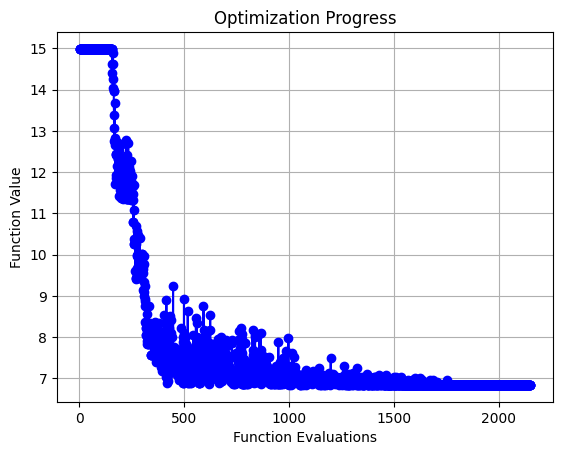

Final Function Value: -11.15625
Total Function Evaluations: 2152


In [50]:
for i in range(len(fvals)):
    fvals[i] = 18 + fvals[i]
# Plot the optimization progress
plt.plot(nfev, fvals, marker='o', linestyle='-', color='b')
plt.xlabel('Function Evaluations')
plt.ylabel('Function Value')
plt.title('Optimization Progress')
plt.grid(True)
plt.show()

# Print final results
print('Final Function Value:', result.fun)
print('Total Function Evaluations:', result.nfev)

In [53]:
df4 = pd.DataFrame({'fes': nfev, 'error': fvals}).dropna()
df4.to_csv("COBYLA.csv", sep='\t')

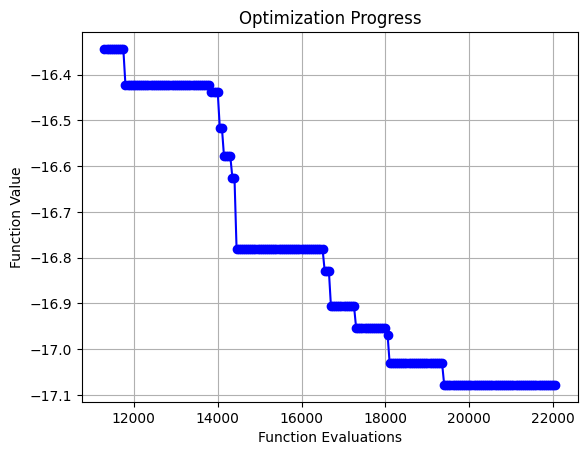

In [56]:
import matplotlib.pyplot as plt

# Read the file and parse the data
file_path = 'HS1.txt'

# Initialize lists to store the extracted data
nfev = []
func_vals = []

with open(file_path, 'r') as file:
    for line in file:
        if ">>>Problem" in line:
            # Extract the function value
            parts = line.split(',')
            for part in parts:
                if "Current best" in part:
                    func_val = float(part.split(':')[-1].strip())
                    func_vals.append(func_val)
        else:
            # Extract the number of function evaluations
            try:
                nfev.append(int(line.strip()))
            except ValueError:
                # Handle the case where the line is not an integer
                continue

# Plot the data
plt.plot(nfev, func_vals, marker='o', linestyle='-', color='b')
plt.xlabel('Function Evaluations')
plt.ylabel('Function Value')
plt.title('Optimization Progress')
plt.grid(True)
plt.show()


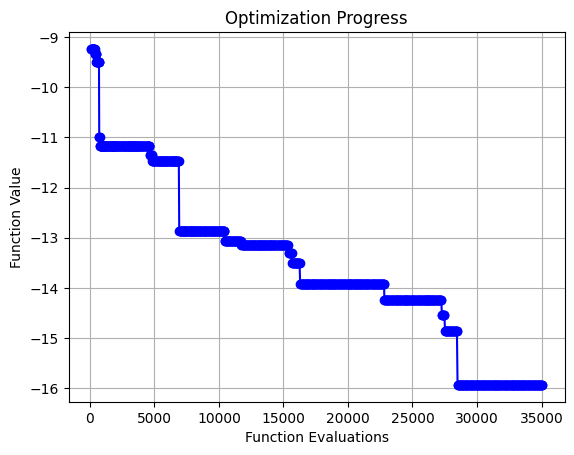

In [57]:
import matplotlib.pyplot as plt

# Read the file and parse the data
file_path = 'iSOMA.txt'

# Initialize lists to store the extracted data
fvals = []
nfev = []

with open(file_path, 'r') as file:
    for line in file:
        if line.startswith("FEs:"):
            parts = line.split()
            nfev.append(int(parts[1]))
        elif line.startswith("Best individual:"):
            parts = line.split()
            fval = float(parts[2].strip('[]'))
            fvals.append(fval)

# Plot the data
plt.plot(nfev, fvals, marker='o', linestyle='-', color='b')
plt.xlabel('Function Evaluations')
plt.ylabel('Function Value')
plt.title('Optimization Progress')
plt.grid(True)
plt.show()
